# Home Task

**Dataset:** TMDB 5000 Movies  
Download: https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata  

In [ ]:
import pandas as pd

movies = pd.read_csv('data/tmdb_5000_movies.csv')

print(f'Movies: {len(movies)}')
print(f'Columns: {list(movies.columns)}') # print columns for reference
movies[['title', 'vote_count', 'vote_average']].head()

Всього фільмів: 4803
Колонки: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']


,title,vote_count,vote_average
0,Avatar,11800,7.2
1,Pirates of the Caribbean: At World's End,4500,6.9
2,Spectre,4466,6.3
3,The Dark Knight Rises,9106,7.6
4,John Carter,2124,6.1


In [43]:
# C = average rating across all movies
# If a movie has few votes, its rating "gravitates" towards C
C = movies['vote_average'].mean()
print(f'Average rating across all movies (C) = {C}')

# m = minimum number of votes to qualify for the top 10% movies
m = movies['vote_count'].quantile(0.90)
print(f'Minimum votes threshold (m, 90th percentile) = {m}')

# Keep only candidates with enough votes
qualified = movies[movies['vote_count'] >= m].copy()
print(f'Movies after filtering: {len(qualified)}')

Average rating across all movies (C) = 6.092171559442016
Minimum votes threshold (m, 90th percentile) = 1838.4000000000015
Movies after filtering: 481


In [44]:
def weighted_rating(row, m=m, C=C):
    v = row['vote_count'] 
    R = row['vote_average']  
    return (v / (v + m)) * R + (m / (v + m)) * C

qualified['score'] = qualified.apply(weighted_rating, axis=1)

# Sort by score and take top 15
top15 = qualified.sort_values('score', ascending=False).head(15)
top15[['title', 'vote_count', 'vote_average', 'score']].reset_index(drop=True)

,title,vote_count,vote_average,score
0,The Shawshank Redemption,8205,8.5,8.059258
1,Fight Club,9413,8.3,7.939256
2,The Dark Knight,12002,8.2,7.920020
3,Pulp Fiction,8428,8.3,7.904645
4,Inception,13752,8.1,7.863239
5,The Godfather,5893,8.4,7.851236
6,Interstellar,10867,8.1,7.809479
7,Forrest Gump,7927,8.2,7.803188
8,The Lord of the Rings: The Return of the King,8064,8.1,7.727243
9,The Empire Strikes Back,5879,8.2,7.697884


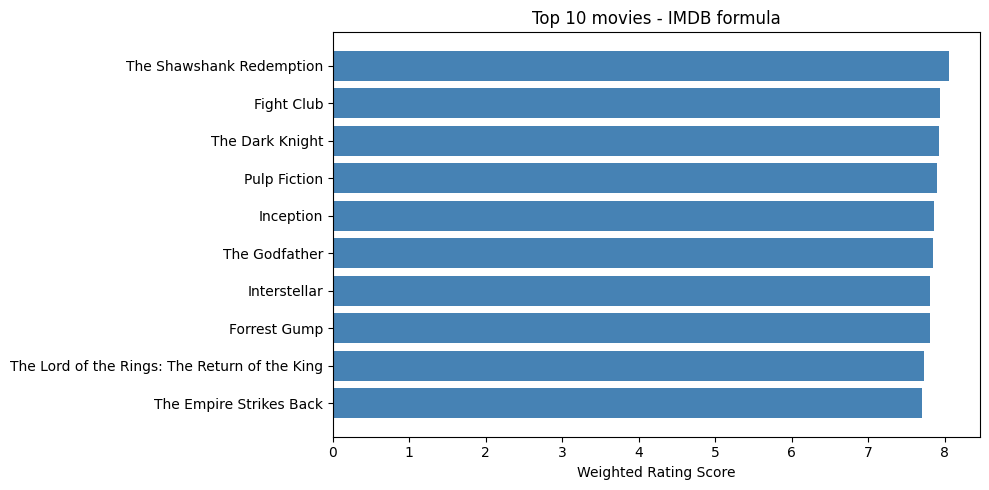

In [46]:
import matplotlib.pyplot as plt

# Visualization of top 10
top10 = top15.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top10['title'][::-1], top10['score'][::-1], color='steelblue')
plt.xlabel('Weighted Rating Score')
plt.title('Top 10 movies - IMDB formula')
plt.tight_layout()
plt.show()

# Content-Based Recommender (optional)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

# Fill empty values with empty string - TfidfVectorizer doesn't like NaN
movies['overview'] = movies['overview'].fillna('')

# Build TF-IDF matrix: row = movie, column = word
# stop_words='english' removes insignificant words ('the', 'a', 'is', ...)
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['overview'])

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}') # (rows = movies, columns = unique words)

TF-IDF matrix shape: (4803, 20978)
(rows = movies, columns = unique words)


In [48]:
# Calculate cosine similarity between each movie and every other
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

print(f'Similarity matrix shape: {cosine_sim.shape}')

Similarity matrix shape: (4803, 4803)


In [49]:
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

def get_recommendations(title, cosine_sim=cosine_sim, n=10):
    """
    Returns n movies that are most similar to title by description.
    """
    if title not in indices:
        return f'Movie "{title}" not found in dataset'
    
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))              
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    movie_indices = [i[0] for i in sim_scores]
    
    result = movies[['title', 'vote_average']].iloc[movie_indices].copy()
    result['similarity'] = [round(s[1], 4) for s in sim_scores]
    return result.reset_index(drop=True)

get_recommendations('The Dark Knight')

,title,vote_average,similarity
0,The Dark Knight Rises,7.6,0.3015
1,Batman Returns,6.6,0.2494
2,"Batman: The Dark Knight Returns, Part 2",7.9,0.2245
3,Batman Forever,5.2,0.2141
4,Batman,7.0,0.1823
5,Batman Begins,7.5,0.1620
6,JFK,7.5,0.1346
7,Batman v Superman: Dawn of Justice,5.7,0.1186
8,Slow Burn,5.5,0.1137
9,Batman & Robin,4.2,0.1069


In [ ]:
get_recommendations('Fight Club')

,title,vote_average,similarity
0,UHF,6.7,0.1153
1,Project X,6.5,0.0920
2,The Hurt Locker,7.2,0.0915
3,Raging Bull,7.7,0.0903
4,The Animal,4.6,0.0817
5,Blast from the Past,6.3,0.0773
6,Go for It!,4.6,0.0765
7,Freaky Deaky,4.9,0.0763
8,"Dancer, Texas Pop. 81",10.0,0.0753
9,This Is Martin Bonner,6.6,0.0750
